### 1. Data Preparation:

In [76]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

df = pd.read_excel('US Superstore data.xls')
df.head()



,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


### 2. Data Visualization with Matplotlib:

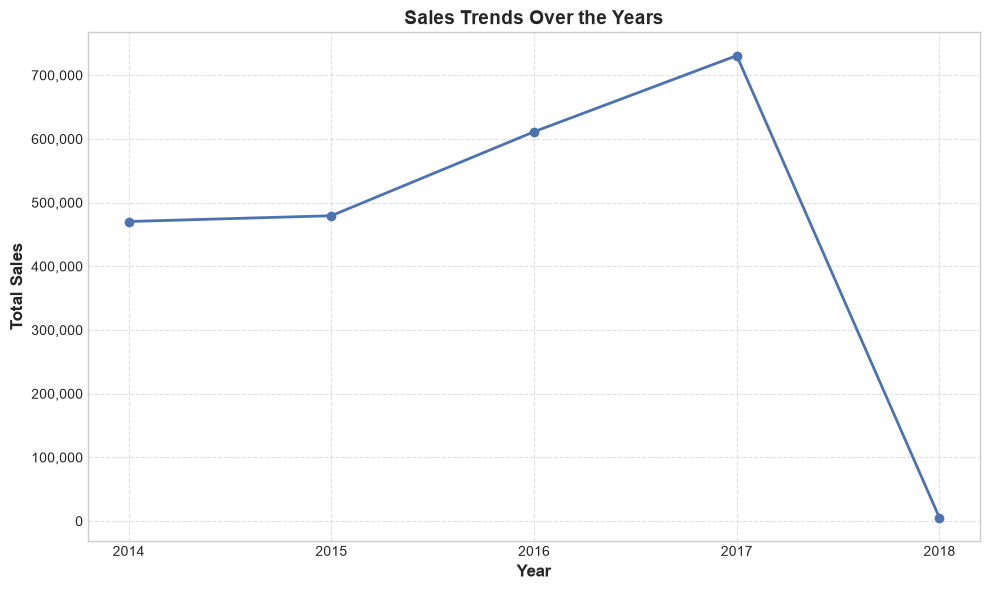

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,2014-01-21,2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2017-121258,2017-02-26,2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2017-121258,2017-02-26,2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2017-121258,2017-02-26,2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


In [ ]:
df['Ship Date'] = pd.to_datetime(df['Ship Date']).dt.year

df_gb = df.groupby('Ship Date').agg(tot_sales=('Sales', 'sum')).reset_index()

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df_gb['Ship Date'], df_gb['tot_sales'], marker='o', linewidth=2, color='#4C72B0')

ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Sales', fontsize=12, fontweight='bold')
ax.set_title('Sales Trends Over the Years', fontsize=14, fontweight='bold')
ax.set_xticks(df_gb['Ship Date'])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

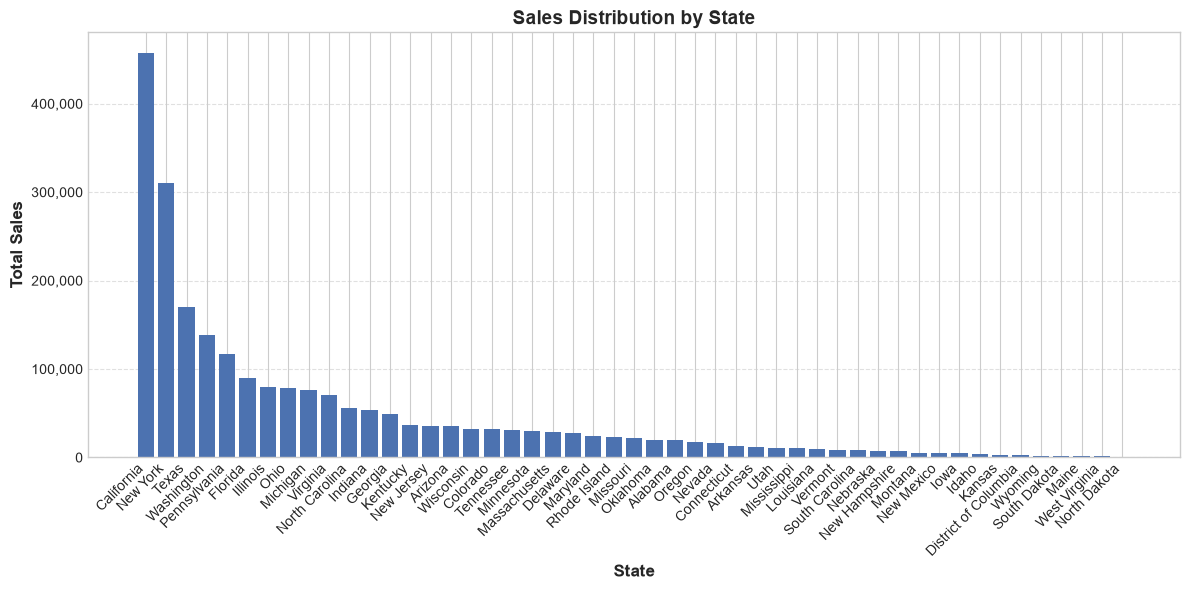

In [78]:
df.columns

df_gb = df.groupby('State').agg(tot_sales=('Sales', 'sum')).reset_index()
df_gb = df_gb.sort_values('tot_sales', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(df_gb['State'], df_gb['tot_sales'], color='#4C72B0')

ax.set_xlabel('State', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Sales', fontsize=12, fontweight='bold')
ax.set_title('Sales Distribution by State', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.xticks(rotation=45, ha='right')
ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### 3. Data Visualization with Seaborn:

C:\Users\avigd\AppData\Local\Temp\ipykernel_6452\4132517888.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, x='tot_sales', y='Product Name', palette='Blues_r')


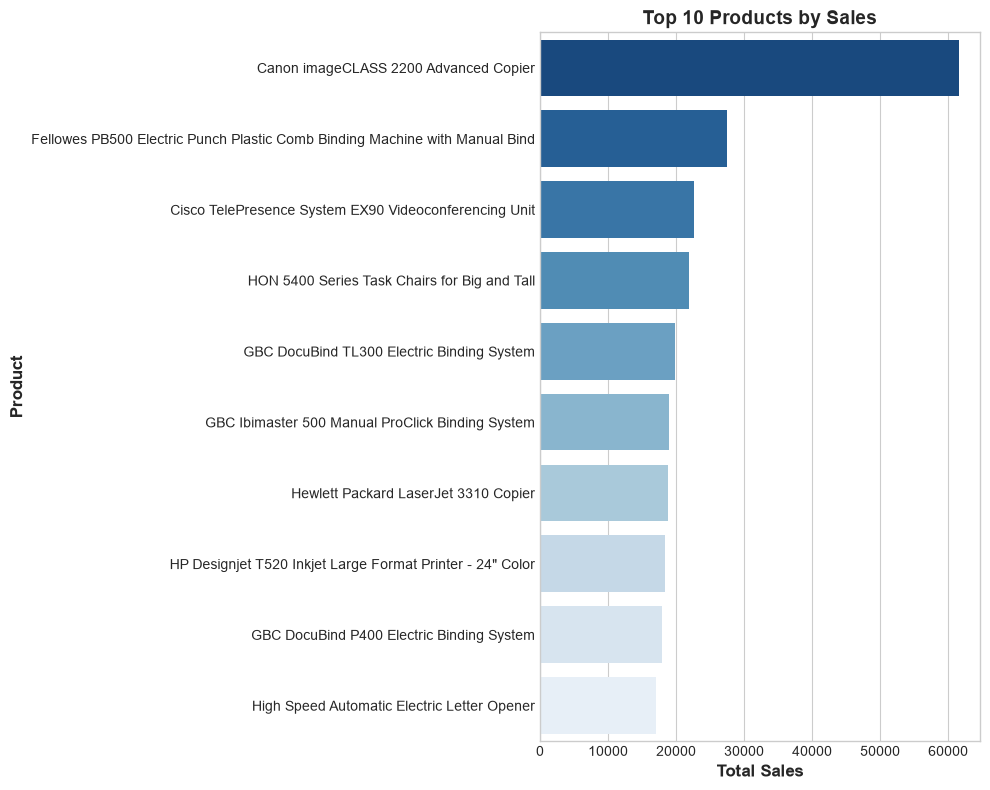

In [79]:
df_gb = df.groupby('Product Name').agg(tot_sales=('Sales', 'sum')).reset_index()
top10 = df_gb.sort_values('tot_sales', ascending=False).head(10)

plt.figure(figsize=(10, 8))
sns.barplot(data=top10, x='tot_sales', y='Product Name', palette='Blues_r')

plt.xlabel('Total Sales', fontsize=12, fontweight='bold')
plt.ylabel('Product', fontsize=12, fontweight='bold')
plt.title('Top 10 Products by Sales', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

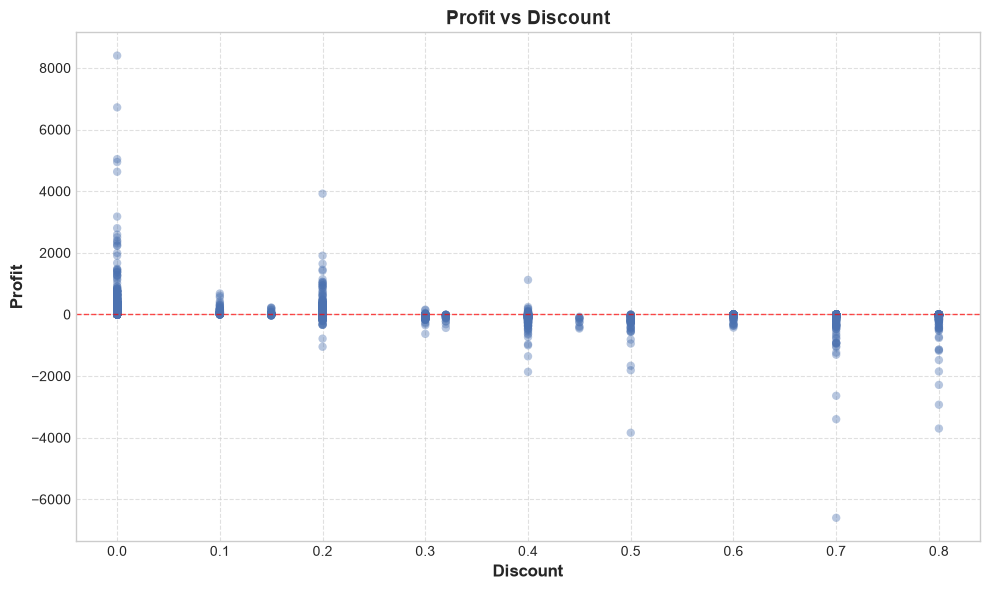

In [80]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(df['Discount'], df['Profit'], alpha=0.4, color='#4C72B0', edgecolor='none')

ax.set_xlabel('Discount', fontsize=12, fontweight='bold')
ax.set_ylabel('Profit', fontsize=12, fontweight='bold')
ax.set_title('Profit vs Discount', fontsize=14, fontweight='bold')
ax.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.7)
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### 4. Comparative Analysis:

Both give the same conclusions about the data, but Seaborn speeds up exploration with less code, while Matplotlib allows more customization when you need it.

### 5. Code and Insights: